# **Task-01**
**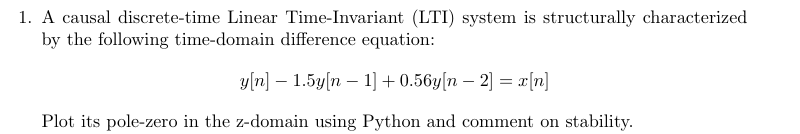

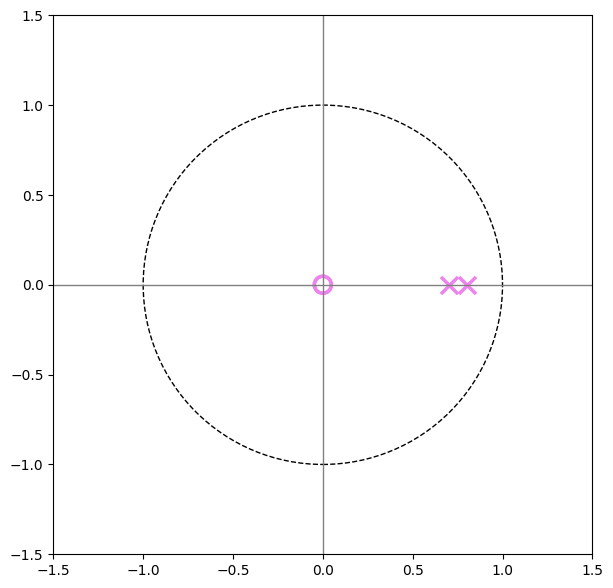

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

numerator = [1, 0, 0]
denominator = [1, -1.5, 0.56]
zeros, poles, gain = signal.tf2zpk(numerator, denominator)
fig, ax = plt.subplots(figsize=(7, 7))
unit_circle = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--')
ax.add_patch(unit_circle)
ax.scatter(np.real(zeros), np.imag(zeros), s=150, marker='o', facecolors='none', edgecolors='violet', linewidths=2.5)
ax.scatter(np.real(poles), np.imag(poles), s=150, marker='x', color='violet', linewidths=2.5)

ax.axhline(0, color='gray', lw=1)
ax.axvline(0, color='gray', lw=1)
ax.set_xlim([-1.5, 1.5])
ax.set_ylim([-1.5, 1.5])
ax.set_aspect('equal')
plt.show()

# **Task-02**
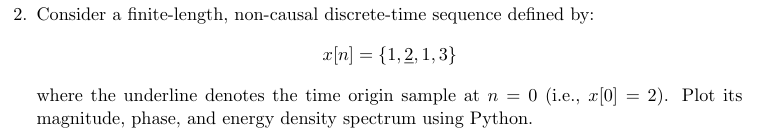

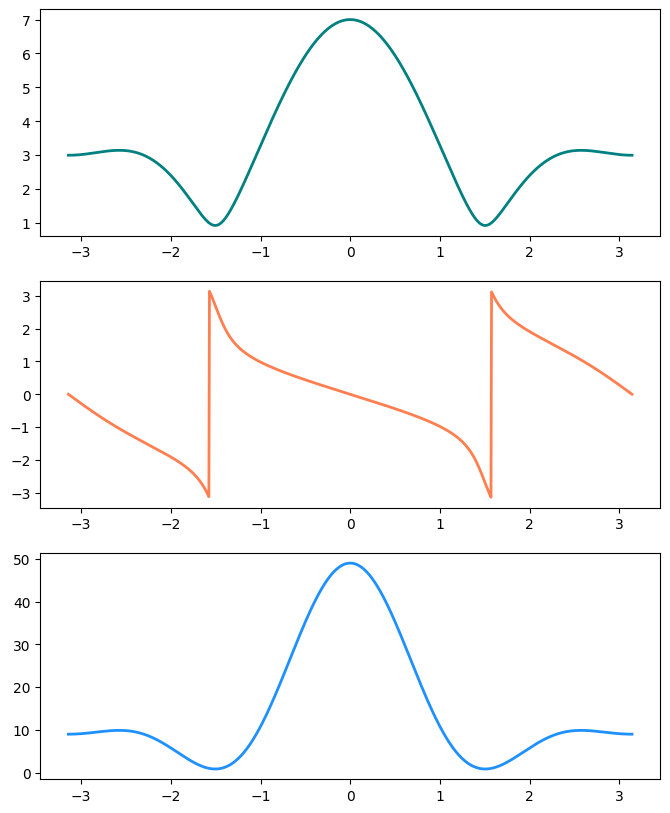

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 2, 1, 3])
n = np.array([-1, 0, 1, 2])
omega = np.linspace(-np.pi, np.pi, 1000)

X_ejw = np.zeros(len(omega), dtype=complex)
for i, w in enumerate(omega):
    X_ejw[i] = np.sum(x * np.exp(-1j * w * n))

magnitude = np.abs(X_ejw)
phase = np.angle(X_ejw)
energy_density = magnitude ** 2

fig, axs = plt.subplots(3, 1, figsize=(8, 10))
axs[0].plot(omega, magnitude, color='teal', linewidth=2)
axs[1].plot(omega, phase, color='coral', linewidth=2)
axs[2].plot(omega, energy_density, color='dodgerblue', linewidth=2)
plt.show()

# **Task-03**
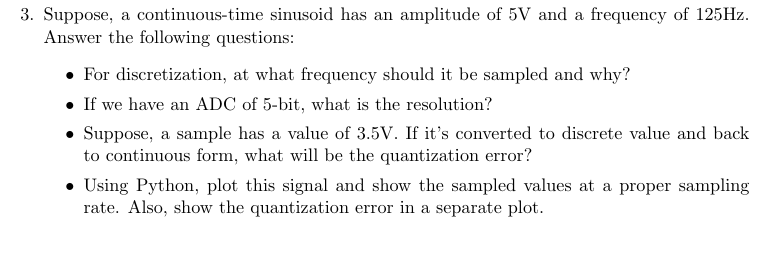

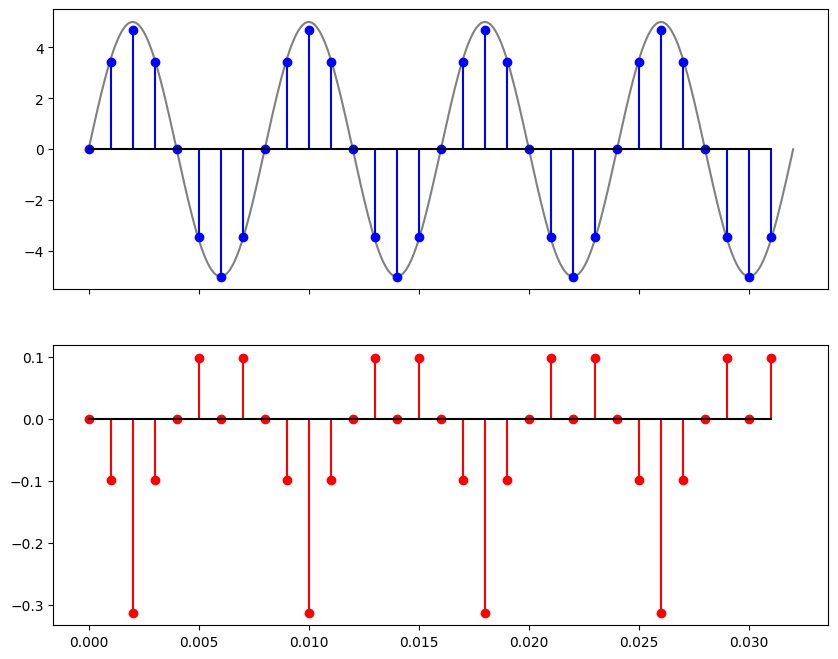

In [3]:
import numpy as np
import matplotlib.pyplot as plt

f_signal = 125
amplitude = 5
V_min, V_max = -5, 5
levels = 2**5
delta = (V_max - V_min) / levels

t_continuous = np.linspace(0, 0.032, 2000)
continuous_signal = amplitude * np.sin(2 * np.pi * f_signal * t_continuous)

f_sample = 1000
t_sampled = np.arange(0, 0.032, 1/f_sample)
sampled_signal = amplitude * np.sin(2 * np.pi * f_signal * t_sampled)

level_indices = np.round((sampled_signal - V_min) / delta)
level_indices = np.clip(level_indices, 0, levels - 1)
quantized_signal = V_min + (level_indices * delta)
quantization_error = quantized_signal - sampled_signal

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax1.plot(t_continuous, continuous_signal, color='gray')
ax1.stem(t_sampled, quantized_signal, linefmt='b-', markerfmt='bo', basefmt='k-')
ax2.stem(t_sampled, quantization_error, linefmt='r-', markerfmt='ro', basefmt='k-')
plt.show()